# Chủ đề: Nghiên cứu xây dựng mô hình học đa tác vụ kết hợp xử lý mất cân bằng lớp cho phân tích phản hồi sinh viên/UIT-VSFC
## Người thực hiện: Nguyễn Thị Thu Trang
## MSSV: 22028254

# Cài đặt, import các thư viện

In [1]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub

In [2]:
import gdown
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import math
import random
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Flatten, BatchNormalization, SimpleRNN
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Embedding, Dense, Dropout, Flatten, LSTM, Bidirectional
import warnings
warnings.filterwarnings('ignore')
import os
import seaborn as sns
import torch
from torch.utils.data import Dataset
from transformers import AutoModel, AutoTokenizer
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

2026-05-24 11:56:08.008692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779623768.233271      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779623768.297472      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779623768.803299      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779623768.803338      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779623768.803341      23 computation_placer.cc:177] computation placer alr

# Cài đặt VnCoreNLP

In [3]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=758bb5cc3d885abf5785929f9b4ed803ce185f7cac0a21d9bbc65b25c3ebbc4c
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-05-24 11:56:52--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M  --.-KB/s    in 0.1s    

2026-05-24 11:56:52 (185 MB/s) - ‘VnCoreNLP

In [4]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


# Tải dữ liệu UIT-VSFC từ Google Drive

In [5]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

In [6]:
df_ = pd.concat([train_df, val_df, test_df])
df_

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
...,...,...,...
3161,"các slide khó hiểu , ngôn ngữ trong slide phức...",0,0
3162,giáo viên giảng dạy có tâm huyết .,2,0
3163,chia sẻ cho em nhiều điều hay .,2,0
3164,em tiếp thu chậm .,0,0


# Kiếm tra phân bố lớp, tỉ lệ mất cân bằng và tính tương hỗ giữa 2 nhãn sentiment và topic

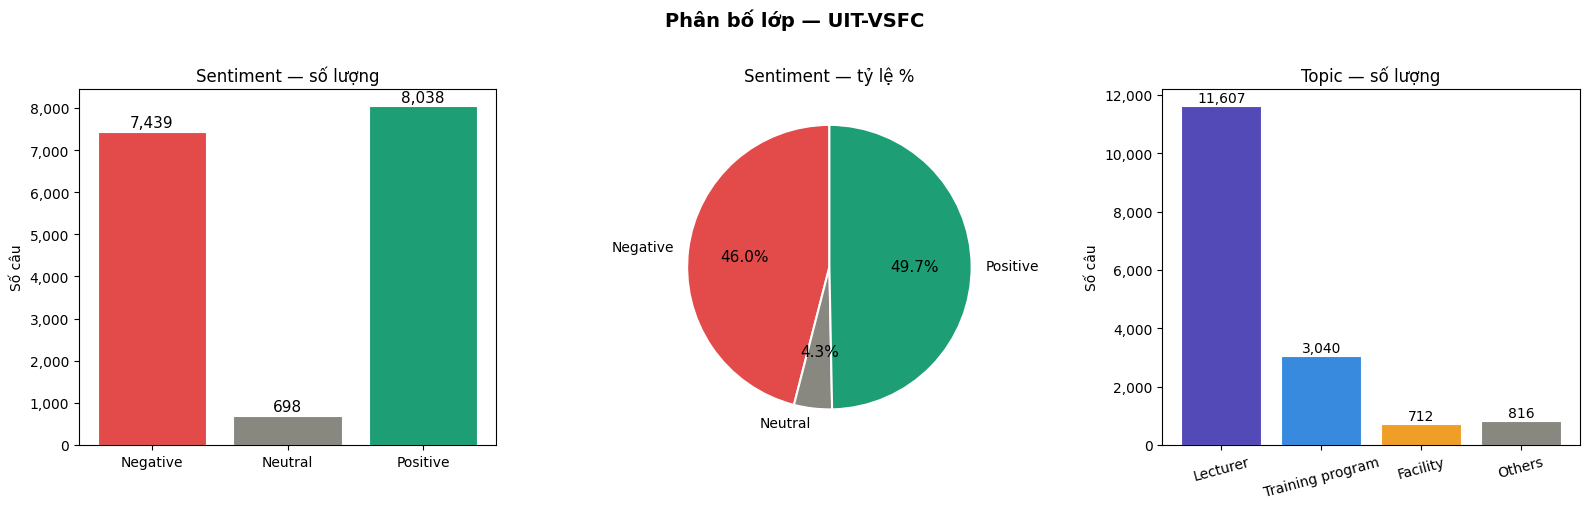

SENTIMENT — imbalance analysis
  Negative              7,439  |  ratio vs majority: 1.08x
  Neutral                 698  |  ratio vs majority: 11.52x
  Positive              8,038  |  ratio vs majority: 1.00x

TOPIC — imbalance analysis
  Lecturer             11,607  |  ratio vs majority: 1.00x
  Training program      3,040  |  ratio vs majority: 3.82x
  Facility                712  |  ratio vs majority: 16.30x
  Others                  816  |  ratio vs majority: 14.22x


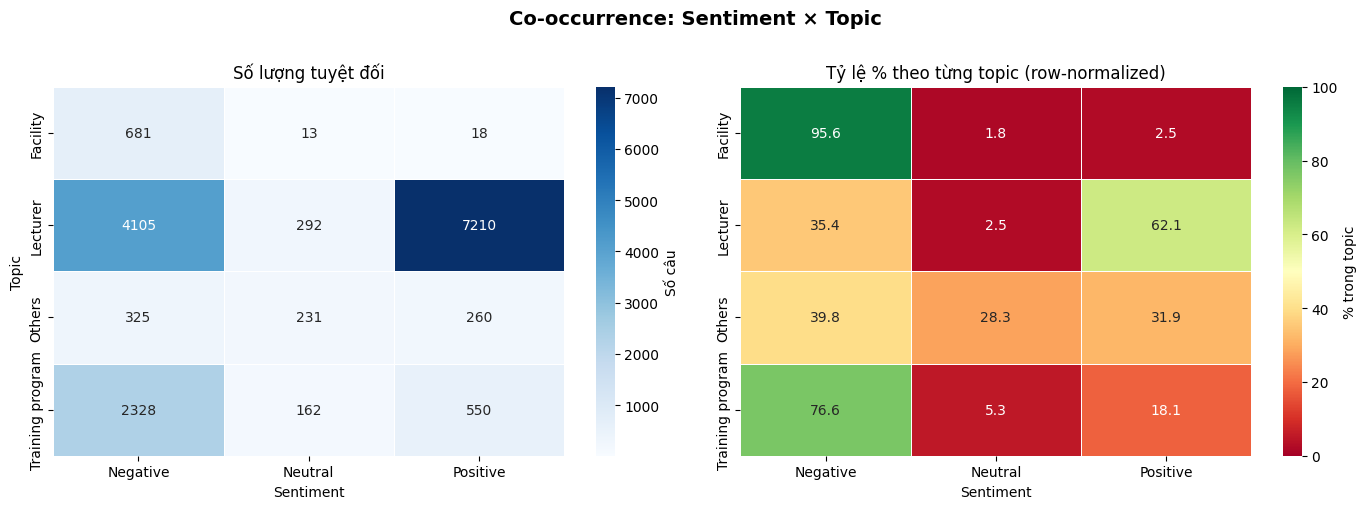

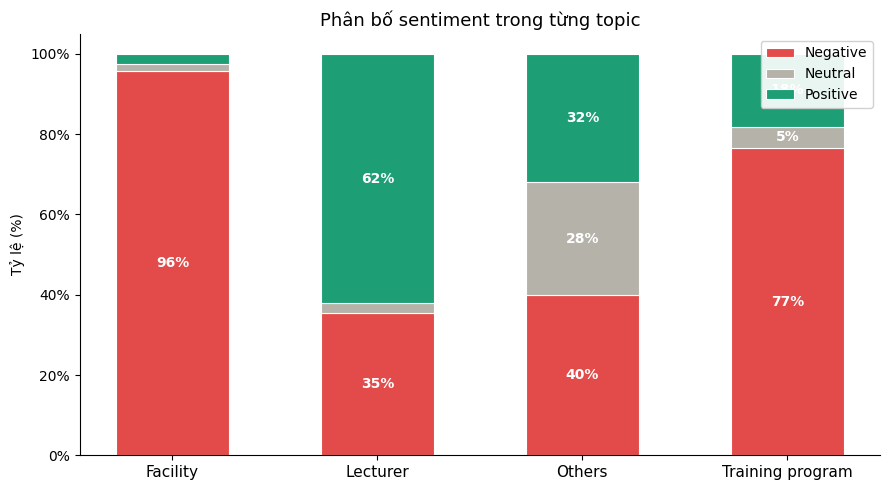


CO-OCCURRENCE TABLE (count)
Sentiment         Negative  Neutral  Positive
Topic                                        
Facility               681       13        18
Lecturer              4105      292      7210
Others                 325      231       260
Training program      2328      162       550

CO-OCCURRENCE TABLE (% row-normalized)
Sentiment         Negative  Neutral  Positive
Topic                                        
Facility              95.6      1.8       2.5
Lecturer              35.4      2.5      62.1
Others                39.8     28.3      31.9
Training program      76.6      5.3      18.1


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# nhãn mapping 
SENTIMENT_MAP = {0: "Negative", 1: "Neutral", 2: "Positive"}
TOPIC_MAP     = {0: "Lecturer", 1: "Training program",
                 2: "Facility", 3: "Others"}

df = df_.copy()
df["sentiment_label"] = df["sentiment"].map(SENTIMENT_MAP)
df["topic_label"]     = df["topic"].map(TOPIC_MAP)

# 1. PHÂN BỐ LỚP — SENTIMENT
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Phân bố lớp — UIT-VSFC", fontsize=14, fontweight="bold", y=1.01)

# 1a. Sentiment count
sent_counts = df["sentiment_label"].value_counts().reindex(
    ["Negative", "Neutral", "Positive"])
colors_sent = ["#E24B4A", "#888780", "#1D9E75"]
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=colors_sent, edgecolor="white", linewidth=0.8)
axes[0].set_title("Sentiment — số lượng")
axes[0].set_ylabel("Số câu")
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))

# 1b. Sentiment percentage
sent_pct = sent_counts / sent_counts.sum() * 100
wedges, texts, autotexts = axes[1].pie(
    sent_pct, labels=sent_pct.index, colors=colors_sent,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5})
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title("Sentiment — tỷ lệ %")

# 1c. Topic count
topic_counts = df["topic_label"].value_counts().reindex(
    ["Lecturer", "Training program", "Facility", "Others"])
colors_topic = ["#534AB7", "#378ADD", "#EF9F27", "#888780"]
bars2 = axes[2].bar(topic_counts.index, topic_counts.values,
                    color=colors_topic, edgecolor="white", linewidth=0.8)
axes[2].set_title("Topic — số lượng")
axes[2].set_ylabel("Số câu")
axes[2].tick_params(axis="x", rotation=15)
for bar, val in zip(bars2, topic_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=10)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. IMBALANCE RATIO
print("=" * 50)
print("SENTIMENT — imbalance analysis")
print("=" * 50)
for label, cnt in sent_counts.items():
    ratio = sent_counts.max() / cnt
    print(f"  {label:<20} {cnt:>6,}  |  ratio vs majority: {ratio:.2f}x")

print()
print("=" * 50)
print("TOPIC — imbalance analysis")
print("=" * 50)
for label, cnt in topic_counts.items():
    ratio = topic_counts.max() / cnt
    print(f"  {label:<20} {cnt:>6,}  |  ratio vs majority: {ratio:.2f}x")

# 3. CO-OCCURRENCE HEATMAP  (sentiment × topic)
co_matrix = pd.crosstab(
    df["topic_label"], df["sentiment_label"],
    rownames=["Topic"], colnames=["Sentiment"]
)[["Negative", "Neutral", "Positive"]]   # cố định thứ tự cột

# 3a. raw count heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Co-occurrence: Sentiment × Topic", fontsize=14,
             fontweight="bold", y=1.01)

sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Số câu"},
            ax=axes[0])
axes[0].set_title("Số lượng tuyệt đối")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Topic")

# 3b. row-normalized (% trong mỗi topic)
co_pct = co_matrix.div(co_matrix.sum(axis=1), axis=0) * 100

sns.heatmap(co_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "% trong topic"},
            vmin=0, vmax=100,
            ax=axes[1])
axes[1].set_title("Tỷ lệ % theo từng topic (row-normalized)")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("cooccurrence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. STACKED BAR — phân bố sentiment bên trong từng topic
fig, ax = plt.subplots(figsize=(9, 5))

x      = np.arange(len(co_pct.index))
width  = 0.55
bottom = np.zeros(len(co_pct))
sent_colors = {"Negative": "#E24B4A", "Neutral": "#B4B2A9", "Positive": "#1D9E75"}

for sentiment in ["Negative", "Neutral", "Positive"]:
    vals = co_pct[sentiment].values
    bars = ax.bar(x, vals, width, bottom=bottom,
                  label=sentiment, color=sent_colors[sentiment],
                  edgecolor="white", linewidth=0.8)
    for bar, v, b in zip(bars, vals, bottom):
        if v > 5:   # chỉ in nếu đủ rộng
            ax.text(bar.get_x() + bar.get_width()/2,
                    b + v/2,
                    f"{v:.0f}%", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(co_pct.index, fontsize=11)
ax.set_ylabel("Tỷ lệ (%)")
ax.set_ylim(0, 105)
ax.set_title("Phân bố sentiment trong từng topic", fontsize=13)
ax.legend(loc="upper right", framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("stacked_bar_topic_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. SUMMARY TABLE — in ra cho báo cáo
print("\n" + "=" * 60)
print("CO-OCCURRENCE TABLE (count)")
print("=" * 60)
print(co_matrix.to_string())

print("\n" + "=" * 60)
print("CO-OCCURRENCE TABLE (% row-normalized)")
print("=" * 60)
print(co_pct.round(1).to_string())

# Tính độ dài câu và tỉ lệ OOV

In [8]:
import torch
import numpy as np
import random
import os
import pandas as pd
from transformers import AutoTokenizer

# Cố định seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Tính độ dài câu và OOV (Sử dụng tokenizer của PhoBERT)
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def analyze_text_complexity(df, text_col="sentence"):
    # Tính độ dài theo word và theo token của PhoBERT
    df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
    df['token_count'] = df[text_col].apply(lambda x: len(tokenizer.tokenize(str(x))))
    
    print(f"Độ dài trung bình (word): {df['word_count'].mean():.2f}")
    print(f"Độ dài tối đa (word): {df['word_count'].max()}")
    
    # Phân tích OOV (Out-of-vocabulary) đơn giản: 
    # Các từ chứa ký tự lạ, teencode chưa có trong vocab của PhoBERT
    vocab = tokenizer.get_vocab()
    def count_oov(text):
        tokens = str(text).split()
        return sum(1 for t in tokens if t not in vocab)
    
    df['oov_count'] = df[text_col].apply(count_oov)
    oov_ratio = df['oov_count'].sum() / df['word_count'].sum() * 100
    print(f"Tỷ lệ OOV ước tính: {oov_ratio:.2f}%")
    
    return df

df = analyze_text_complexity(df)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Độ dài trung bình (word): 14.23
Độ dài tối đa (word): 161
Tỷ lệ OOV ước tính: 1.08%


### Nhận xét:

- Mất cân bằng lớp:
    * Sentiment:  Lớp Neutral (698 mẫu) quá ít so với Positive (8,038). Tỷ lệ lệch lên đến 11.52x
    * Topic: Sự chênh lệch còn khủng khiếp hơn ở mảng Topic. Lecturer chiếm đa số tuyệt đối, trong khi Facility chỉ có 712 mẫu (lệch 16.3x).
- Mối tương quan giữa Sentiment và Topic (Co-occurrence)
    *  Facility (95.6% Negative): Sinh viên hầu như chỉ nhận xét về cơ sở vật chất khi họ... phàn nàn. Điều này khiến mô hình dễ hình thành suy nghĩ sai lệch: "Cứ thấy nhắc đến phòng học, máy chiếu thì chắc chắn là tiêu cực".
    *  Lecturer (62.1% Positive): Ngược lại, giảng viên thường nhận được lời khen.
    *  Others (Phân bố đều nhất): Đây là nhóm khó học nhất vì phân bố sentiment khá đồng đều (39.8% Neg - 28.3% Neu - 31.9% Pos).
- Đặc trưng văn bản:
    * Độ dài trung bình 14.23 từ: Đây là dạng văn bản cực ngắn (Short text). Thông tin ngữ cảnh rất ít, khiến việc phân loại dựa trên từ khóa (keywords) trở nên rủi ro.
    * OOV 1.08%: Tỷ lệ này khá thấp so với các tập dữ liệu mạng xã hội khác (như Twitter), chứng tỏ PhoBERT có thể xử lý tốt từ vựng của UIT-VSFC mà không cần can thiệp quá sâu vào việc thêm vocab mới.

**Hướng giải quyết:**

- Dùng Weighted Loss: Thay vì dùng hàm loss mặc định, hãy tính trọng số cho từng lớp. Lớp nào ít mẫu (như Neutral hay Facility) thì nhân trọng số loss cao hơn.
- Stratified K-Fold: để đảm bảo lớp Neutral luôn xuất hiện đủ ở cả 3 tập Train/Val/Test.
- Metrics: Không dùng Accuracy làm thước đo chính mà dùng Macro F1 score

# Kiểm tra phân bố nhãn trong các tập

In [9]:
# HÀM KIỂM TRA PHÂN BỐ NHÃN TRONG CÁC TẬP
def check_distribution(df, name):
    print(f"\n--- Phân bố tập {name} ({len(df)} mẫu) ---")
    
    # Phân bố Sentiment
    sent_counts = df['sentiment'].value_counts(normalize=True).sort_index() * 100
    print(f"Sentiment (Negative=0, Neutral=1, Positive=2): \n{sent_counts.round(1)}%")
    
    # Phân bố Topic
    topic_counts = df['topic'].value_counts(normalize=True).sort_index() * 100
    print(f"Topic (Lecturer=0, Training=1, Facility=2, Others=3): \n{topic_counts.round(1)}%")

check_distribution(train_df, "TRAIN")
check_distribution(val_df, "VALIDATION")
check_distribution(test_df, "TEST")


--- Phân bố tập TRAIN (11426 mẫu) ---
Sentiment (Negative=0, Neutral=1, Positive=2): 
sentiment
0    46.6
1     4.0
2    49.4
Name: proportion, dtype: float64%
Topic (Lecturer=0, Training=1, Facility=2, Others=3): 
topic
0    71.5
1    19.3
2     4.3
3     4.9
Name: proportion, dtype: float64%

--- Phân bố tập VALIDATION (1583 mẫu) ---
Sentiment (Negative=0, Neutral=1, Positive=2): 
sentiment
0    44.5
1     4.6
2    50.9
Name: proportion, dtype: float64%
Topic (Lecturer=0, Training=1, Facility=2, Others=3): 
topic
0    72.7
1    16.9
2     4.4
3     6.0
Name: proportion, dtype: float64%

--- Phân bố tập TEST (3166 mẫu) ---
Sentiment (Negative=0, Neutral=1, Positive=2): 
sentiment
0    44.5
1     5.3
2    50.2
Name: proportion, dtype: float64%
Topic (Lecturer=0, Training=1, Facility=2, Others=3): 
topic
0    72.3
1    18.1
2     4.6
3     5.0
Name: proportion, dtype: float64%


### Nhận xét:
- Phân bố nhãn giữa các tập train, validation và test tương đối nhất quán, cho thấy việc chia dữ liệu là hợp lý và không gây lệch phân phối đáng kể.
- Ở tác vụ sentiment, hai lớp Negative và Positive chiếm tỷ lệ chủ đạo và gần cân bằng, trong khi lớp Neutral xuất hiện rất ít (~4–5%), phản ánh hiện tượng mất cân bằng lớp.
- Ở tác vụ topic, lớp Lecturer chiếm đa số, còn Facility và Others có tỷ lệ thấp, cho thấy dữ liệu bị lệch mạnh giữa các lớp chủ đề.
- Sự ổn định về phân bố nhãn giữa các tập giúp mô hình được huấn luyện và đánh giá trên dữ liệu có đặc điểm tương đồng.